In [1]:
import time
from enum import Enum
import math
import matplotlib.pyplot as plt
import numpy as np

In [10]:
class PayoffType(str, Enum):
    Call = 'Call'
    Put = 'Put'
    BinaryCall = 'BinaryCall'
    BinaryPut = 'BinaryPut'

In [11]:
def oneStepBinomial(S:float, r:float, u:float, d:float, K:float, T:float, optType:PayoffType) -> float:
    """calculate the one-step binomial option price"""
    p = (math.exp(r*T) - d) / (u - d)
    if optType == PayoffType.Call:
        return math.exp(-r*T) * (p * max(S*u - K, 0) + (1 - p) * max(S*d - K, 0))

def testoneStepBinomial():
    S = 100
    K = 105
    r = 0.01
    u = 1.2
    d = 0.8
    T = 1
    callPrice = oneStepBinomial(S, r, u, d, K, T, PayoffType.Call)
    print(f"One-step binomial call option price: {callPrice:.4f}")

testoneStepBinomial()


One-step binomial call option price: 7.7985


In [14]:
def cnorm(x):
    return (1.0 + math.erf(x / math.sqrt(2.0))) / 2.0

def bsPrice(S, r, vol, T, K, payoffType:PayoffType):
    """calculate Black-Scholes option price"""
    fwd = S * math.exp(r*T)
    stdev = vol * math.sqrt(T)
    d1 = math.log(fwd / K) / stdev + stdev / 2
    d2 = d1 - stdev
    if payoffType == PayoffType.Call:
        return math.exp(-r*T) * (fwd * cnorm(d1) - cnorm(d2) * K)
    elif payoffType == PayoffType.Put:
        return math.exp(-r * T) * (K * cnorm(-d2) - cnorm(-d1) * fwd)
    elif payoffType == PayoffType.BinaryCall:
        return math.exp(-r*T) * cnorm(d1)
    elif payoffType == PayoffType.BinaryPut:
        return math.exp(-r * T) * (1 - cnorm(-d1))
    else:
        raise Exception("not supported payoff type", payoffType)
    
def testoneStepBinomialBS():
# test ---
    S, r, vol, K, T, u, d = 100, 0.01, 0.2, 105, 1.0, 1.2, 0.8
    print("BSPrice: ", bsPrice(S, r, vol, T, K, PayoffType.Call))
    print("oneStepTree: ", oneStepBinomial(S, r, u, d, K, T, PayoffType.Call))
testoneStepBinomialBS()

BSPrice:  6.297254539086019
oneStepTree:  7.798504987524955


In [15]:
def oneStepBinomial2(S:float, r:float, vol:float, optType:PayoffType, K:float, T:float) -> float:
    """calculate the one-step binomial option price"""
    b = math.exp(vol * vol * T + r * T) + math.exp(-r*T)
    u = (b + math.sqrt(b*b - 4)) / 2
    d = 1/u
    p = (math.exp(r*T) - d) / (u - d)
    if optType == PayoffType.Call:
        return math.exp(-r*T) * (p * max(S*u - K, 0) + (1 - p) * max(S*d - K, 0))
    
def testoneStepBinomialBS():
# test ---
    S, r, vol, K, T, u, d = 100, 0.01, 0.2, 105, 1.0, 1.2, 0.8
    print("BSPrice: ", bsPrice(S, r, vol, T, K, PayoffType.Call))
    print("oneStepTree1: ", oneStepBinomial(S, r, u, d, K, T, PayoffType.Call))
    print("oneStepTree2: ", oneStepBinomial2(S, r, vol, PayoffType.Call, K, T))
testoneStepBinomialBS()

BSPrice:  6.297254539086019
oneStepTree1:  7.798504987524955
oneStepTree2:  8.212289615248919


blackPrice: 	 6.297254539086019
crrNStepTree: 	 6.296057152109465
crr Binomial Tree pricing time:  0.0026619434356689453
BS close form formula pricing time:  3099.4415283203125


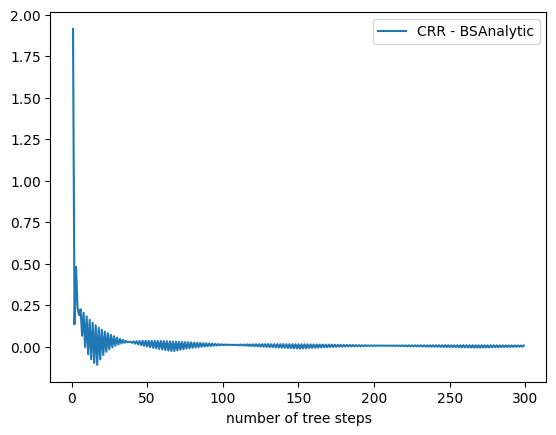

In [18]:
def crrBinomial(S:float, r:float, vol:float, payoffType:PayoffType, K:float, T:float, n:int) -> float:
    """calculate the one-step binomial option price"""
    t = T / n
    b = math.exp(vol * vol * t + r * t) + math.exp(-r*t)
    u = (b + math.sqrt(b*b - 4)) / 2
    d = 1/u
    p = (math.exp(r*t) - d) / (u - d)
    payoffDict = {
        PayoffType.Call: lambda s: max(s-K, 0),
        PayoffType.Put: lambda s: max(K-s, 0),
    }
    # get final state
    vs = [payoffDict[payoffType]( S * u**(n-i-i)) for i in range(n+1)]
    # iterate backward
    for i in range(n-1, -1, -1): 
        # iterate through each timestep
        # we already have last state so only n-1 states left
        # take backwards step one at a time therefore -1. until 0 ( -1 is exclusive)
        for j in range(i+1):
            # there are i+1 nodes at timestep i, calculate each node value
            vs[j] = math.exp(-r*t) * (vs[j] * p + vs[j+1] * (1 - p)) 
            # take two nodes from future step to calculate current node
            # replace the top node index. this will mix the current and future values
            # but its ok since in the next iteration we dont need the upper nodes anymore
            # example once we calculate vs[0] at time 0, we dont need vs[1] and vs[2] anymore
    return vs[0]

def testoneStepBinomialBSPlot():
    # test ---
    S, r, vol, K, T = 100, 0.01, 0.2, 105, 1.0
    print("blackPrice: \t", bsPrice(S, r, vol, T, K, PayoffType.Call))
    print("crrNStepTree: \t", crrBinomial(S, r, vol, PayoffType.Call, K, T, 300))

    start = time.time()
    crrBinomial(S, r, vol, PayoffType.Call, K, T, 200)
    print("crr Binomial Tree pricing time: ", time.time() - start)

    start = time.time()
    bsPrice(S, r, vol, T, K, PayoffType.Call)
    print("BS close form formula pricing time: ", (time.time() - start) * 1e9)

    import matplotlib.pyplot as plt
    n = 300
    S, r, vol, K, T = 100, 0.01, 0.2, 105, 1.0
    bsPrc = bsPrice(S, r, vol, T, K, PayoffType.Call)
    crrErrs = [(crrBinomial(S,r,vol,PayoffType.Call,K,T,i) - bsPrc) for i in range(1, n)]

    plt.plot(range(1, n), crrErrs, label = "CRR - BSAnalytic")
    plt.xlabel('number of tree steps')
    plt.legend()
    # plt.yscale('log')
    plt.show()
    
testoneStepBinomialBSPlot()

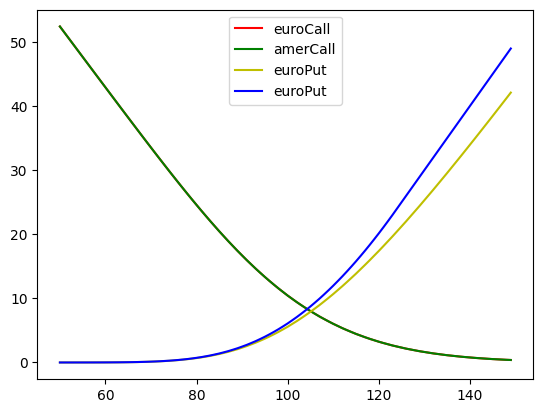

In [ ]:
class EuropeanOption:
    def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S-self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S,0)
        elif self.payoffType == PayoffType.BinaryCall:
            if S > self.strike:
                return 1.0
            else:
                return 0.0
        elif self.payoffType == PayoffType.BinaryPut:
            if S < self.strike:
                return 1.0
            else:
                return 0.0
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
    def valueAtNode(self, t, S, continuation):
        if continuation == None:
            return self.payoff(S)
        else:
            return continuation
    """European options always pass on conitnuation value because they only exercise at expiry. 
    so payoff funciton is only used at expiry"""
        
class AmericanOption:
    def __init__(self, expiry, strike, payoffType):
        self.expiry = expiry
        self.strike = strike
        self.payoffType = payoffType
    def payoff(self, S):
        if self.payoffType == PayoffType.Call:
            return max(S-self.strike, 0)
        elif self.payoffType == PayoffType.Put:
            return max(self.strike - S,0)
        else:
            raise Exception("payoffType not supported: ", self.payoffType)
    def valueAtNode(self, t, S, continuation):
        return max(self.payoff(S), continuation)
    """American options need to be valued at each node to decide if exercising is better than continuation."""
    
class BarrierOption():
    def __init__(self, downBarrier, upBarrier, barrierStart, barrierEnd, underlyingOption):
        self.underlyingOption = underlyingOption
        self.barrierStart = barrierStart
        self.barrierEnd = barrierEnd
        self.downBarrier = downBarrier
        self.upBarrier = upBarrier
        self.expiry = underlyingOption.expiry
    def payoff(self, S):
        return self.underlyingOption.payoff(S)
    def valueAtNode(self, t, S, continuation):
        # if the time is within the barrier active period
        if t>=self.barrierStart and t <= self.barrierEnd:
            # and if the spot breaches the barrier the KO and value is 0
            if self.upBarrier != None and S > self.upBarrier:
                return 0.0
            elif self.downBarrier != None and S < self.downBarrier:
                return 0.0
        return continuation
    """Barrier options are more like american in the sense that they can be is triggered before expiry"""

class AsianOption():
    def __init__(self, fixings, payoffFun, As, nT):
        self.fixings = fixings
        self.payoffFun = payoffFun
        self.expiry = fixings[-1]
        self.nFixings = len(fixings)
        self.As, self.nT = nT
        self.dt = self.expiry / nT
    def onFixingDate(self, t):
        # we say t is on a fixing date if there is a fixing date T_i \in (t-dt, t]
        return filter(lambda x: x > t - self.dt and x<=t, self.fixings)
    def valueAtNode(self, t, S, continuation):
        if continuation == None:
            return [self.payoffFun((a*(self.nFixings-1) + S)/self.nFixings) for a in self.As]
        else:
            if self.onFixingDate(t):
                i = len(filter(lambda x: x < t, self.fixings)) # number of previous fixings
                Ahats = [(a*(i-1) + S)/i for a in self.As]
                nodeValues = [np.interp(a, self.As, continuation) for a in Ahats]
            else:
                nodeValues = continuation
        return nodeValues
    
def crrBinomialG(S:float, r:float, vol:float, trade, n:int) -> float:
    """calculate the one-step binomial option price"""
    t = trade.expiry / n
    b = math.exp(vol * vol * t + r * t) + math.exp(-r*t)
    u = (b + math.sqrt(b*b - 4)) / 2
    p = (math.exp(r*t) - 1/u) / (u - 1/u)
    # get final state
    vs = [trade.payoff( S * u**(n-i-i)) for i in range(n+1)]
    # iterate backward
    for i in range(n-1, -1, -1): 
        for j in range(i+1):
            # there are i+1 nodes at timestep i, calculate each node value
            nodeS = S * u**(i-j-j)
            continuation = math.exp(-r*t) * (vs[j] * p + vs[j+1] * (1-p))
            vs[j] = trade.valueAtNode(t*i, nodeS, continuation)
    return vs[0]

def crrBinomialGAmeEur():
# testing binomial tree pricer with American Option
    euroPrc, amerPrc = [],  []
    S, r, vol = 100, 0.05, 0.2
    ks = range(50, 150)
    for k in ks:
        euroPrc.append(crrBinomialG(S, r, vol, EuropeanOption(1, float(k), PayoffType.Call), 300))
        amerPrc.append(crrBinomialG(S, r, vol, AmericanOption(1, float(k), PayoffType.Call), 300))
    plt.plot(ks, euroPrc, 'r', label = 'euroCall')
    plt.plot(ks, amerPrc, 'g', label = 'amerCall')
    euroPrc, amerPrc = [],  []
    for k in ks:
        euroPrc.append(crrBinomialG(S, r, vol, EuropeanOption(1, float(k), PayoffType.Put), 300))
        amerPrc.append(crrBinomialG(S, r, vol, AmericanOption(1, float(k), PayoffType.Put), 300))
    plt.plot(ks, euroPrc, 'y', label = 'euroPut')
    plt.plot(ks, amerPrc, 'b', label = 'euroPut')
    plt.legend()
    # plt.savefig('../figs/amerPrice.eps', format='eps')

crrBinomialGAmeEur()

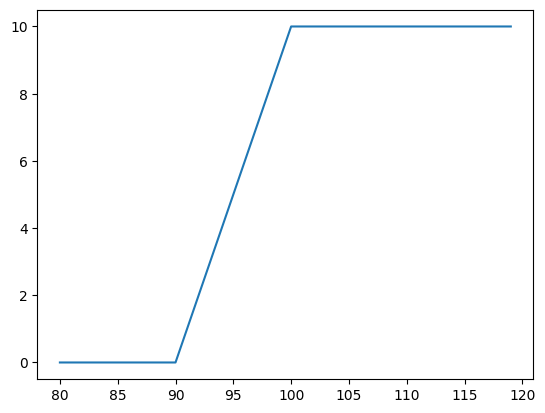

Euro callspread:  6.259190489574921
Amer callspread:  10.0


In [32]:
class EuropeanPayoff():
    def __init__(self, expiry, payoffFun):
        self.expiry = expiry
        self.payoffFun = payoffFun
    def payoff(self, S):
        return self.payoffFun(S)
    def valueAtNode(self, t, S, continuation):
        return continuation

class AmericanPayoff():
    def __init__(self, expiry, payoffFun):
        self.expiry = expiry
        self.payoffFun = payoffFun
    def payoff(self, S):
        return self.payoffFun(S)
    def valueAtNode(self, t, S, continuation):
        return max(self.payoff(S), continuation)
    
def testAmerSpreadCRR():
    S, r, vol = 100, 0.05, 0.2
    callSpread = lambda S: min(max(S - 90, 0), 10)
    plt.plot(range(80, 120), [callSpread(i) for i in range(80, 120)])
    plt.show()
    print("Euro callspread: ", crrBinomialG(S, r, vol, EuropeanPayoff(1, callSpread), 300))
    print("Amer callspread: ", crrBinomialG(S, r, vol, AmericanPayoff(1, callSpread), 300))

    # instead of lambda, we can also define payoff function separately
    # we can make t as another payofftype within class of AmericanOption/EuropeanOption fn payoff()

if __name__ == "__main__":
    testAmerSpreadCRR()


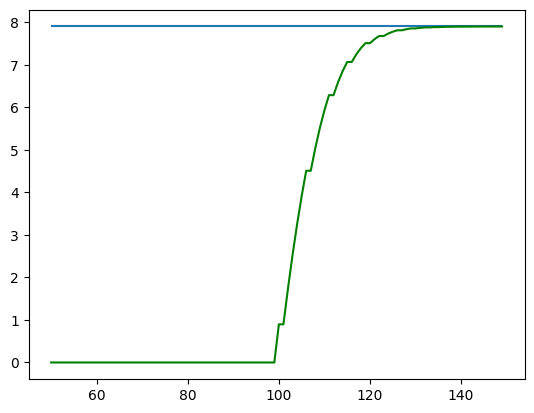

In [ ]:
def testUpBarrier():
    S, r, vol , k = 100, 0.05, 0.2, 105
    # set up options, use european put as underlying
    eurOpt = EuropeanOption(1, k, PayoffType.Put)
    # set up tree pricer 
    euroPrc = crrBinomialG(S, r, vol, eurOpt, 300)
    # set up experiment conditions, barrier option computed prices and the range of barrier values
    barrierPrc, ks = [], range(50, 150)
    # iterate through the range of barrier values
    for barrierLevel in ks:
        # get barrier option price at given barrier level
        prc = crrBinomialG(S, 
                           r, 
                           vol, 
                           BarrierOption(
                               downBarrier = None,
                               upBarrier = barrierLevel, 
                               barrierStart = 0, 
                               barrierEnd = 1, 
                               underlyingOption = eurOpt), 
                           n = 300)
        barrierPrc.append(prc)
    plt.hlines(euroPrc, ks[0], ks[-1], label = "euroPrc")
    plt.plot(ks, barrierPrc, "g", label="barrierPrc")


testUpBarrier()


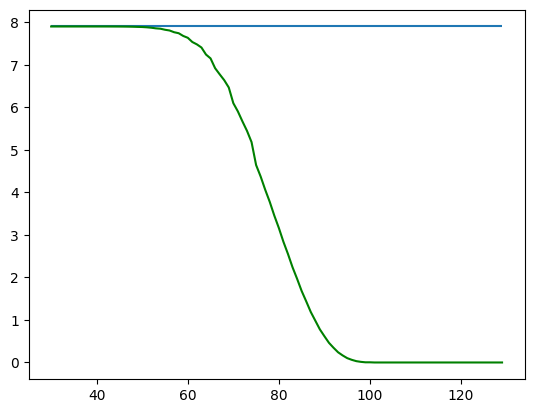

In [36]:
def testDownBarrier():
    S, r, vol , k = 100, 0.05, 0.2, 105
    # set up options, use european put as underlying
    eurOpt = EuropeanOption(1, k, PayoffType.Put)
    # set up tree pricer 
    euroPrc = crrBinomialG(S, r, vol, eurOpt, 300)
    # set up experiment conditions, barrier option computed prices and the range of barrier values
    barrierPrc, ks = [], range(30, 130)
    # iterate through the range of barrier values
    for barrierLevel in ks:
        # get barrier option price at given barrier level
        prc = crrBinomialG(S, 
                           r, 
                           vol, 
                           BarrierOption(
                               downBarrier = barrierLevel,
                               upBarrier = None, 
                               barrierStart = 0, 
                               barrierEnd = 1, 
                               underlyingOption = eurOpt), 
                           n = 300)
        barrierPrc.append(prc)
    plt.hlines(euroPrc, ks[0], ks[-1], label = "euroPrc")
    plt.plot(ks, barrierPrc, "g", label="barrierPrc")


testDownBarrier()


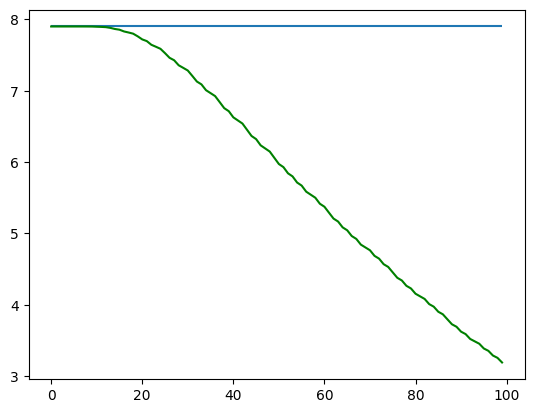

In [37]:
def testWindowBarrier():
    S, r, vol , k = 100, 0.05, 0.2, 105
    # set up options, use european put as underlying
    eurOpt = EuropeanOption(1, k, PayoffType.Put)
    # set up tree pricer 
    euroPrc = crrBinomialG(S, r, vol, eurOpt, 300)
    # set up experiment conditions, barrier option computed prices and the range of barrier values
    barrierPrc, ks = [], range(0, 100)
    # iterate through the range of barrier values
    for t in ks:
        # get barrier option price at given barrier level
        prc = crrBinomialG(S, 
                           r, 
                           vol, 
                           BarrierOption(
                               downBarrier = 80,
                               upBarrier = 150, 
                               barrierStart = 0, 
                               barrierEnd = t/100, 
                               underlyingOption = eurOpt), 
                           n = 300)
        barrierPrc.append(prc)
    plt.hlines(euroPrc, ks[0], ks[-1], label = "euroPrc")
    plt.plot(ks, barrierPrc, "g", label="barrierPrc")


testWindowBarrier()


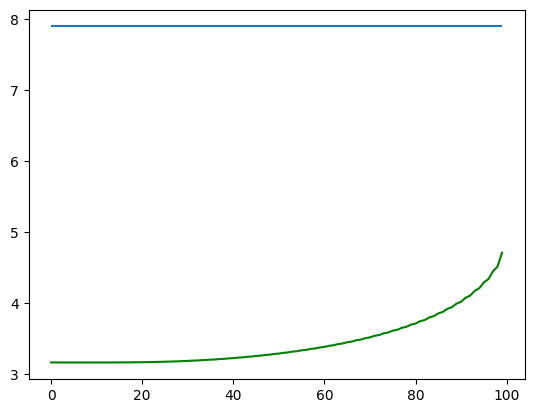

In [39]:
def testWindowBarrier2():
    S, r, vol , k = 100, 0.05, 0.2, 105
    # set up options, use european put as underlying
    eurOpt = EuropeanOption(1, k, PayoffType.Put)
    # set up tree pricer 
    euroPrc = crrBinomialG(S, r, vol, eurOpt, 300)
    # set up experiment conditions, barrier option computed prices and the range of barrier values
    barrierPrc, ks = [], range(0, 100)
    # iterate through the range of barrier values
    for t in ks:
        # get barrier option price at given barrier level
        prc = crrBinomialG(S, 
                           r, 
                           vol, 
                           BarrierOption(
                               downBarrier = 80,
                               upBarrier = 150, 
                               barrierStart = t/100, 
                               barrierEnd = 1, 
                               underlyingOption = eurOpt), 
                           n = 300)
        barrierPrc.append(prc)
    plt.hlines(euroPrc, ks[0], ks[-1], label = "euroPrc")
    plt.plot(ks, barrierPrc, "g", label="barrierPrc")


testWindowBarrier2()
